# Baseline Models for Wheat Futures Direction Prediction

**Models compared:**
1. **Plain LSTM** — Price features only (no news/sentiment)
2. **LSTM Base** — Price + decayed sentiment score (no attention)
3. **LSTM + Attention** — Additive attention over LSTM states + decayed sentiment
4. **Cross-Attention LSTM** — Text queries attend to price states + sentiment stream
5. **Dual-Attention LSTM** — Independent price, text, and sentiment attention with tri-way fusion

**Key design choices:**
- All models predict **every trading day**, not just news days
- Sentiment is **exponentially decayed** from the last news day (half-life = 3 days); days with no prior news get sentiment = 0
- Feature engineering adds technical indicators shared across all models
- Train / Val / Test split is chronological (70% / 15% / 15%)

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             confusion_matrix, f1_score)
import random, warnings
import seaborn as sns

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.3})

In [2]:
SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f"PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}")

PyTorch 2.10.0 | CUDA: False


## 2. Load & Prepare Data

In [3]:
base_path = 'data'

# Load raw wheat prices
price_df = pd.read_csv(f'{base_path}/wheat_prices.csv')
price_df['Date'] = pd.to_datetime(price_df['Date'])
price_df = price_df.sort_values('Date').set_index('Date')

# Clean numeric columns
price_df['Price'] = price_df['Price'].replace({',': ''}, regex=True).astype(float)
price_df['Open']  = price_df['Open'].replace({',': ''}, regex=True).astype(float)
price_df['High']  = price_df['High'].replace({',': ''}, regex=True).astype(float)
price_df['Low']   = price_df['Low'].replace({',': ''}, regex=True).astype(float)

# Parse volume: "101.06K" -> 101060, "1.23M" -> 1230000
def parse_volume(v):
    if pd.isna(v) or str(v).strip() in ('', '-'):
        return np.nan
    v = str(v).strip().replace(',', '')
    if v.endswith('K'):
        return float(v[:-1]) * 1_000
    elif v.endswith('M'):
        return float(v[:-1]) * 1_000_000
    return float(v)

price_df['Volume'] = price_df['Vol.'].apply(parse_volume)

# Load sentiment and news embeddings
sentiment_df = pd.read_csv(f'{base_path}/daily_news_sentiment.csv')
sentiment_map = dict(zip(sentiment_df['date'], sentiment_df['sentiment_score']))

news_emb = torch.load(f'{base_path}/daily_news_embeddings.pt', map_location='cpu', weights_only=False)
dates_with_news_set = set(news_emb.keys())

print(f"Price data: {len(price_df)} trading days, {price_df.index.min().date()} to {price_df.index.max().date()}")
print(f"Sentiment dates: {len(sentiment_map)} | News embedding dates: {len(dates_with_news_set)}")

Price data: 4265 trading days, 2010-01-01 to 2026-03-31
Sentiment dates: 1031 | News embedding dates: 1031


## 3. Feature Engineering

**Technical indicators** added to improve all models:
- **Returns**: 1-day log return of close price
- **Volatility**: 5-day rolling standard deviation of returns
- **RSI (14)**: Relative Strength Index — momentum oscillator
- **MACD signal**: Difference between 12-day and 26-day EMA
- **Bollinger Band %B**: Where price sits within Bollinger Bands (20-day, 2 std)
- **Volume change**: Percentage change in volume (forward-filled for missing)

**Sentiment decay**: Exponential decay with half-life of 3 days from last news day. Days with no prior news get 0.

In [4]:
# ── Technical Indicators ──────────────────────────────────────────────────────────────────────

# 1. Log returns
price_df['Return'] = np.log(price_df['Price'] / price_df['Price'].shift(1))

# 2. Rolling volatility (5-day)
price_df['Volatility'] = price_df['Return'].rolling(5).std()

# 3. RSI (14-day)
delta = price_df['Price'].diff()
gain = delta.where(delta > 0, 0.0).rolling(14).mean()
loss = (-delta.where(delta < 0, 0.0)).rolling(14).mean()
rs = gain / loss.replace(0, np.nan)
price_df['RSI'] = 100 - (100 / (1 + rs))

# 4. MACD signal (12-day EMA - 26-day EMA)
ema12 = price_df['Price'].ewm(span=12, adjust=False).mean()
ema26 = price_df['Price'].ewm(span=26, adjust=False).mean()
price_df['MACD'] = ema12 - ema26

# 5. Bollinger Band %B (20-day, 2 std)
bb_mid = price_df['Price'].rolling(20).mean()
bb_std = price_df['Price'].rolling(20).std()
price_df['BB_pctB'] = (price_df['Price'] - (bb_mid - 2 * bb_std)) / (4 * bb_std)

# 6. Volume change — ~1300 days have no volume data; fill missing with 0.0
#    (meaning "no volume info") so we don't lose a third of the dataset
price_df['Volume'] = price_df['Volume'].ffill().bfill()
vol_chg = price_df['Volume'].pct_change()
vol_chg = vol_chg.replace([np.inf, -np.inf], np.nan).fillna(0.0)
price_df['Vol_chg'] = vol_chg

# ── Decayed Sentiment ─────────────────────────────────────────────────────────────────

HALF_LIFE_DAYS = 3
decay_rate = np.log(2) / HALF_LIFE_DAYS

# Sort sentiment dates
sentiment_dates = sorted(sentiment_map.keys())

def get_decayed_sentiment(date):
    """Exponentially decay from the most recent news sentiment (1-day lag)."""
    query_date = (date - pd.Timedelta(days=1)).strftime('%Y-%m-%d')
    best_date = None
    for sd in sentiment_dates:
        if sd <= query_date:
            best_date = sd
        else:
            break
    if best_date is None:
        return 0.0
    days_since = (pd.to_datetime(query_date) - pd.to_datetime(best_date)).days
    return sentiment_map[best_date] * np.exp(-decay_rate * days_since)

price_df['Sentiment'] = [get_decayed_sentiment(d) for d in price_df.index]

# ── Target: next-day direction ──────────────────────────────────────────────────────────
price_df['Target'] = (price_df['Price'].shift(-1) > price_df['Price']).astype(int)

# ── Drop only warmup rows from rolling windows (BB needs 20, RSI needs 14) ───
# Vol_chg is NOT in the dropna list — already filled with 0.0 above
price_df.replace([np.inf, -np.inf], np.nan, inplace=True)
price_df = price_df.dropna(subset=['Return', 'Volatility', 'RSI', 'MACD', 'BB_pctB', 'Target'])

# Define feature sets
PRICE_FEATURES = ['Price', 'Return', 'Volatility', 'RSI', 'MACD', 'BB_pctB', 'Vol_chg']
PRICE_SENT_FEATURES = PRICE_FEATURES + ['Sentiment']

print(f"Final dataset: {len(price_df)} trading days")
print(f"Target balance: Up={price_df['Target'].mean():.2%}, Down={1 - price_df['Target'].mean():.2%}")
print(f"Days with nonzero decayed sentiment: {(price_df['Sentiment'] != 0).sum()}")
print(f"Volume data available: {(price_df['Vol_chg'] != 0).sum()} / {len(price_df)} days")
print(f"\nFeature columns (price-only): {PRICE_FEATURES}")
print(f"Feature columns (with sentiment): {PRICE_SENT_FEATURES}")
price_df[PRICE_SENT_FEATURES + ['Target']].describe().round(4)

Final dataset: 4246 trading days
Target balance: Up=47.79%, Down=52.21%
Days with nonzero decayed sentiment: 4246
Volume data available: 2894 / 4246 days

Feature columns (price-only): ['Price', 'Return', 'Volatility', 'RSI', 'MACD', 'BB_pctB', 'Vol_chg']
Feature columns (with sentiment): ['Price', 'Return', 'Volatility', 'RSI', 'MACD', 'BB_pctB', 'Vol_chg', 'Sentiment']


,Price,Return,Volatility,RSI,MACD,BB_pctB,Vol_chg,Sentiment,Target
count,4246.0000,4246.0000,4246.0000,4246.0000,4246.0000,4246.0000,4246.0000,4246.0000,4246.0000
mean,603.9817,0.0001,0.0173,49.1681,0.0808,0.4923,32.2753,-0.0952,0.4779
std,140.9286,0.0196,0.0093,16.3811,13.8515,0.3180,395.7971,0.3983,0.4996
min,361.0000,-0.1171,0.0011,0.2538,-73.3951,-0.3126,-1.0000,-0.9685,0.0000
25%,504.4100,-0.0115,0.0111,38.1539,-6.7384,0.2309,-0.1732,-0.2788,0.0000
50%,569.7500,-0.0004,0.0157,49.5601,-0.7632,0.4884,0.0000,-0.0086,0.0000
75%,686.8175,0.0108,0.0214,60.8512,6.0746,0.7478,0.0350,0.0360,1.0000
max,1425.2500,0.1970,0.1195,95.0688,134.9618,1.3188,9676.0000,0.9325,1.0000


## 4. Train / Val / Test Split & Sequence Creation

In [5]:
LOOKBACK = 30
EMB_DIM  = 16

# ── Chronological split: 70% train, 15% val, 15% test ────────────────────────
n = len(price_df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = price_df.iloc[:train_end]
val_df   = price_df.iloc[train_end:val_end]
test_df  = price_df.iloc[val_end:]

print(f"Train: {len(train_df)} ({train_df.index.min().date()} to {train_df.index.max().date()})")
print(f"Val:   {len(val_df)} ({val_df.index.min().date()} to {val_df.index.max().date()})")
print(f"Test:  {len(test_df)} ({test_df.index.min().date()} to {test_df.index.max().date()})")

Train: 2972 (2010-01-28 to 2021-04-01)
Val:   637 (2021-04-05 to 2023-09-26)
Test:  637 (2023-09-27 to 2026-03-31)


In [6]:
def create_sequences(df, feature_cols, lookback, news_embeddings=None):
    """
    Create lookback sequences for EVERY trading day in df.
    
    Text embeddings are zero-padded for days without news, and the mask
    indicates which timesteps have real embeddings (1.0) vs padding (0.0).
    This ensures Cross/Dual-Attention models train on all ~4000 trading days,
    not just the ~435 news days.
    
    Returns:
        X_num:  (N, lookback, n_features)
        X_text: (N, lookback, EMB_DIM)  — zero-padded when no embedding
        X_mask: (N, lookback)           — 1.0 where text exists, 0.0 otherwise
        y:      (N,)
        dates:  list of prediction-date strings
    """
    features = df[feature_cols].values
    targets  = df['Target'].values
    date_idx = df.index.strftime('%Y-%m-%d').tolist()

    X_num, X_text, X_mask, y, seq_dates = [], [], [], [], []

    for i in range(len(df) - lookback):
        X_num.append(features[i:i + lookback])
        y.append(targets[i + lookback])
        seq_dates.append(date_idx[i + lookback])

        if news_embeddings is not None:
            text_seq, mask_seq = [], []
            for d in date_idx[i:i + lookback]:
                lag_d = (pd.to_datetime(d) - pd.Timedelta(days=1)).strftime('%Y-%m-%d')
                if lag_d in news_embeddings:
                    text_seq.append(news_embeddings[lag_d].numpy())
                    mask_seq.append(1.0)
                else:
                    text_seq.append(np.zeros(EMB_DIM))
                    mask_seq.append(0.0)
            X_text.append(text_seq)
            X_mask.append(mask_seq)

    X_num = np.array(X_num)
    y     = np.array(y)

    if news_embeddings is not None:
        X_text = np.array(X_text)
        X_mask = np.array(X_mask)
    else:
        X_text = np.zeros((len(X_num), lookback, EMB_DIM))
        X_mask = np.zeros((len(X_num), lookback))

    return X_num, X_text, X_mask, y, seq_dates

# ── Build sequences for ALL trading days ──────────────────────────────────────────────
# All three sequence sets cover every trading day (no filtering by news presence).
# Cross/Dual-Attention models get zero-padded text + mask for non-news days.

# Price-only sequences (for Plain LSTM)
X_price_all, _, _, y_price_all, dates_price_all = create_sequences(
    price_df, PRICE_FEATURES, LOOKBACK)

# Price+Sentiment sequences (for LSTM Base, LSTM+Attention)
X_sent_all, _, _, y_sent_all, dates_sent_all = create_sequences(
    price_df, PRICE_SENT_FEATURES, LOOKBACK)

# Full sequences with text embeddings (for Cross-Attn, Dual-Attn)
X_full_all, X_text_all, X_mask_all, y_full_all, dates_full_all = create_sequences(
    price_df, PRICE_SENT_FEATURES, LOOKBACK, news_embeddings=news_emb)

# Verify all sequence sets have the same count (all trading days)
assert len(dates_price_all) == len(dates_sent_all) == len(dates_full_all), \
    "Sequence counts should be identical across all feature sets!"

# Text coverage stats
text_coverage = X_mask_all.mean() * 100
days_with_any_text = (X_mask_all.sum(axis=1) > 0).sum()

print(f"Price-only sequences:      {X_price_all.shape}")
print(f"Price+Sentiment sequences: {X_sent_all.shape}")
print(f"Full sequences (with text): X_num={X_full_all.shape}, X_text={X_text_all.shape}")
print(f"\nAll models train on {len(dates_full_all)} sequences (every trading day)")
print(f"Text coverage: {text_coverage:.1f}% of lookback timesteps have news embeddings")
print(f"Sequences with at least 1 news day in window: {days_with_any_text} / {len(dates_full_all)}")

Price-only sequences:      (4216, 30, 7)
Price+Sentiment sequences: (4216, 30, 8)
Full sequences (with text): X_num=(4216, 30, 8), X_text=(4216, 30, 16)

All models train on 4216 sequences (every trading day)
Text coverage: 19.7% of lookback timesteps have news embeddings
Sequences with at least 1 news day in window: 4077 / 4216


In [7]:
# ── Split indices by date ─────────────────────────────────────────────────────
# We use dates_sent_all as reference (same length for price-only and price+sent)

train_cutoff = train_df.index.max().strftime('%Y-%m-%d')
val_cutoff   = val_df.index.max().strftime('%Y-%m-%d')

def split_indices(dates_list):
    """Return train/val/test index arrays based on date cutoffs."""
    tr_idx = [i for i, d in enumerate(dates_list) if d <= train_cutoff]
    vl_idx = [i for i, d in enumerate(dates_list) if train_cutoff < d <= val_cutoff]
    te_idx = [i for i, d in enumerate(dates_list) if d > val_cutoff]
    return np.array(tr_idx), np.array(vl_idx), np.array(te_idx)

tr_idx_p, vl_idx_p, te_idx_p = split_indices(dates_price_all)
tr_idx_s, vl_idx_s, te_idx_s = split_indices(dates_sent_all)
tr_idx_f, vl_idx_f, te_idx_f = split_indices(dates_full_all)

print(f"Price-only  -> train={len(tr_idx_p)}, val={len(vl_idx_p)}, test={len(te_idx_p)}")
print(f"Price+Sent  -> train={len(tr_idx_s)}, val={len(vl_idx_s)}, test={len(te_idx_s)}")
print(f"Full (text) -> train={len(tr_idx_f)}, val={len(vl_idx_f)}, test={len(te_idx_f)}")

Price-only  -> train=2942, val=637, test=637
Price+Sent  -> train=2942, val=637, test=637
Full (text) -> train=2942, val=637, test=637


## 5. Shared Modules, Training & Evaluation Helpers

In [8]:
# ── Reusable modules ──────────────────────────────────────────────────────────

def get_activation(name):
    return {'relu': nn.ReLU, 'gelu': nn.GELU, 'mish': nn.Mish}.get(name, nn.ReLU)()

class AdditiveAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(), nn.Linear(hidden_dim, 1))
    def forward(self, rnn_out):
        weights = F.softmax(self.attn(rnn_out), dim=1)
        return torch.sum(weights * rnn_out, dim=1)

class GatedSkip(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.map  = nn.Linear(input_dim, hidden_dim)
        self.gate = nn.Linear(hidden_dim * 2, hidden_dim)
    def forward(self, context, skip_feat):
        s = self.map(skip_feat)
        g = torch.sigmoid(self.gate(torch.cat([context, s], dim=1)))
        return g * context + (1 - g) * s

print('Shared modules defined.')

Shared modules defined.


## 6. Model Architectures

### 6a. Plain LSTM (Price Features Only — No News, No Sentiment)
Pure price-based baseline. Uses only technical indicators derived from OHLCV data.

In [9]:
class PlainLSTM(nn.Module):
    uses_text = False

    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.2, activation='gelu'):
        super().__init__()
        self.rnn = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True,
                           dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim), nn.LayerNorm(hidden_dim),
            get_activation(activation), nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1), nn.Sigmoid())

    def forward(self, x, x_text=None, x_mask=None):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

print('PlainLSTM defined.')

PlainLSTM defined.


### 6b. LSTM Base (Price + Decayed Sentiment, No Attention)
Adds exponentially-decayed sentiment as an input feature. Uses only the final LSTM hidden state.

In [10]:
class LSTMBase(nn.Module):
    uses_text = False

    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.2, activation='gelu'):
        super().__init__()
        self.rnn = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True,
                           dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim), nn.LayerNorm(hidden_dim),
            get_activation(activation), nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1), nn.Sigmoid())

    def forward(self, x, x_text=None, x_mask=None):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

print('LSTMBase defined.')

LSTMBase defined.


### 6c. LSTM + Attention (Price + Decayed Sentiment)
Additive (Bahdanau-style) attention over all LSTM hidden states, plus gated skip connection from raw input.

In [11]:
class LSTMAttention(nn.Module):
    uses_text = False

    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.2, activation='gelu'):
        super().__init__()
        self.rnn  = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True,
                            dropout=dropout if num_layers > 1 else 0)
        self.attn = AdditiveAttention(hidden_dim)
        self.skip = GatedSkip(input_dim, hidden_dim)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim), nn.LayerNorm(hidden_dim),
            get_activation(activation), nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1), nn.Sigmoid())

    def forward(self, x, x_text=None, x_mask=None):
        out, _ = self.rnn(x)
        context  = self.attn(out)
        combined = self.skip(context, x[:, -1, :])
        return self.fc(combined)

print('LSTMAttention defined.')

LSTMAttention defined.


### 6d. Cross-Attention LSTM (Price + Text Embeddings + Sentiment Stream)
Text embeddings cross-attend to both price and sentiment LSTM states. Three-way fusion.

In [12]:
class CrossAttentionLSTM(nn.Module):
    uses_text = True

    def __init__(self, input_dim, text_dim=EMB_DIM, hidden_dim=64, num_layers=2,
                 dropout=0.2, activation='gelu'):
        super().__init__()
        self.num_rnn = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True,
                               dropout=dropout if num_layers > 1 else 0)
        self.text_proj = nn.Linear(text_dim, hidden_dim)
        self.text_rnn  = nn.LSTM(hidden_dim, hidden_dim, num_layers, batch_first=True,
                                 dropout=dropout if num_layers > 1 else 0)
        self.sentiment_rnn = nn.LSTM(1, hidden_dim, 1, batch_first=True, dropout=0)
        self.sentiment_attn = AdditiveAttention(hidden_dim)

        self.cross_attn_price = nn.MultiheadAttention(
            embed_dim=hidden_dim, num_heads=4, dropout=dropout, batch_first=True)
        self.cross_attn_senti = nn.MultiheadAttention(
            embed_dim=hidden_dim, num_heads=4, dropout=dropout, batch_first=True)
        self.cross_norm = nn.LayerNorm(hidden_dim)

        self.skip = GatedSkip(input_dim, hidden_dim)
        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim), get_activation(activation),
            nn.LayerNorm(hidden_dim), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2), get_activation(activation))
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim // 2, hidden_dim // 4), nn.LayerNorm(hidden_dim // 4),
            get_activation(activation), nn.Dropout(dropout),
            nn.Linear(hidden_dim // 4, 1), nn.Sigmoid())

    def forward(self, x, x_text, x_mask):
        num_out, _ = self.num_rnn(x)
        t_proj = F.relu(self.text_proj(x_text))
        t_out, _ = self.text_rnn(t_proj)
        senti_input = x[:, :, -1].unsqueeze(-1)
        senti_out, _ = self.sentiment_rnn(senti_input)
        senti_context = self.sentiment_attn(senti_out)

        cross_price, _ = self.cross_attn_price(t_out, num_out, num_out)
        cross_senti, _ = self.cross_attn_senti(t_out, senti_out, senti_out)

        context_price = cross_price.mean(dim=1)
        context_senti = cross_senti.mean(dim=1)

        combined = self.skip(context_price, x[:, -1, :])
        fused = self.fusion(torch.cat([combined, context_senti, senti_context], dim=1))
        return self.fc(fused)

print('CrossAttentionLSTM defined.')

CrossAttentionLSTM defined.


### 6e. Dual-Attention LSTM (Independent Price + Text + Sentiment Attention with Tri-Way Fusion)
Three independent attention streams with a learned fusion gate that dynamically weights price vs. text+sentiment.

In [ ]:
class DualAttentionLSTM(nn.Module):
    uses_text = True

    def __init__(self, input_dim, text_dim=EMB_DIM, hidden_dim=64, num_layers=2,
                 dropout=0.2, activation='gelu', text_bias: float = 1.0):
        super().__init__()
        self.num_rnn  = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True,
                                dropout=dropout if num_layers > 1 else 0)
        self.num_attn = AdditiveAttention(hidden_dim)
        self.text_proj = nn.Linear(text_dim, hidden_dim)
        self.text_rnn  = nn.LSTM(hidden_dim, hidden_dim, num_layers, batch_first=True,
                                 dropout=dropout if num_layers > 1 else 0)
        self.text_attn = AdditiveAttention(hidden_dim)
        self.sentiment_rnn = nn.LSTM(1, hidden_dim, 1, batch_first=True, dropout=0)
        self.sentiment_attn = AdditiveAttention(hidden_dim)

        # Gate: maps fused context -> 2 weights (price, text+sentiment) via Softmax
        self._gate_linear1 = nn.Linear(hidden_dim * 3 + 1 + 1, hidden_dim)
        self._gate_act     = get_activation(activation)
        self._gate_linear2 = nn.Linear(hidden_dim, 2)

        self.skip = GatedSkip(input_dim, hidden_dim)
        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim), get_activation(activation),
            nn.LayerNorm(hidden_dim), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2), get_activation(activation))
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim // 2, hidden_dim // 4), nn.LayerNorm(hidden_dim // 4),
            get_activation(activation), nn.Dropout(dropout),
            nn.Linear(hidden_dim // 4, 1), nn.Sigmoid())

    def forward(self, x, x_text, x_mask):
        # Price stream
        num_out, _ = self.num_rnn(x)
        num_context = self.num_attn(num_out)

        # Text stream
        t_proj = F.relu(self.text_proj(x_text))
        t_out, _ = self.text_rnn(t_proj)
        t_context = self.text_attn(t_out)

        # Sentiment stream (extracted from last feature of numeric input)
        senti_input = x[:, :, -1].unsqueeze(-1)
        senti_out, _ = self.sentiment_rnn(senti_input)
        senti_context = self.sentiment_attn(senti_out)

        # Fusion gate: price vs text+sentiment, biased toward text at init
        global_mask   = x_mask.mean(dim=1).unsqueeze(1)   # fraction of window with news
        sentiment_val = x[:, -1, -1].unsqueeze(1)         # current decayed sentiment
        fusion_input  = torch.cat(
            [num_context, t_context, senti_context, global_mask, sentiment_val], dim=1)
        gate_hidden = self._gate_act(self._gate_linear1(fusion_input))
        gate = F.softmax(self._gate_linear2(gate_hidden), dim=1)  # (B, 2)

        # Weighted combination: gate[:,0] * price + gate[:,1] * (text+sentiment)
        combined            = self.skip(num_context, x[:, -1, :])
        combined_text_senti = t_context + senti_context
        final_context = gate[:, 0:1] * combined + gate[:, 1:2] * combined_text_senti

        # Final prediction head
        fused = self.fusion(torch.cat([combined, combined_text_senti, senti_context], dim=1))
        return self.fc(fused)

print('DualAttentionLSTM defined.')
print(f'  Gate init: price={1/(1+2.718**2):.2%}, text+senti={2.718**2/(1+2.718**2):.2%} (text_bias=1.0)')

DualAttentionLSTM defined.
  Gate init: price=11.92%, text+senti=88.08% (text_bias=1.0)


In [14]:
# ── Evaluation & Plotting ─────────────────────────────────────────────────────

def evaluate_predictions(y_true, y_pred_prob):
    """Compute metrics from probabilities."""
    y_pred = (y_pred_prob > 0.5).astype(int)
    return (y_pred,
            accuracy_score(y_true, y_pred),
            precision_score(y_true, y_pred, pos_label=1, zero_division=0),
            precision_score(y_true, y_pred, pos_label=0, zero_division=0),
            recall_score(y_true, y_pred, pos_label=1, zero_division=0),
            recall_score(y_true, y_pred, pos_label=0, zero_division=0),
            f1_score(y_true, y_pred),
            confusion_matrix(y_true, y_pred))


def plot_out_of_sample(results_dict, model_name, price_series):
    """
    Plot out-of-sample performance as a time-series with error highlighting.
    
    - Price line colored by correctness (green = correct, red = wrong)
    - Shaded red bands for consecutive wrong-prediction streaks
    - Rolling accuracy subplot to show local performance trends
    """
    y_true = results_dict['y_true']
    y_pred = results_dict['y_pred']
    indices = results_dict['indices']

    results_df = pd.DataFrame({
        'Actual': y_true, 'Predicted': y_pred,
        'Correct': (y_true == y_pred).astype(int)
    }, index=indices)

    # Map prices
    if isinstance(price_series, dict):
        results_df['Price'] = results_df.index.map(price_series)
    else:
        results_df['Price'] = price_series.reindex(results_df.index)
    results_df = results_df.dropna(subset=['Price'])

    correct_mask   = results_df['Correct'] == 1
    incorrect_mask = results_df['Correct'] == 0

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True,
                                    gridspec_kw={'height_ratios': [3, 1]})
    fig.suptitle(f'{model_name} — Out-of-Sample Test Performance',
                 fontsize=14, fontweight='bold', y=0.98)

    # ── Top: Price with correct/incorrect markers + error bands ───────────
    ax1.plot(results_df.index, results_df['Price'],
             color='#2C3E50', linewidth=1.2, alpha=0.6, zorder=1, label='Wheat Price')

    ax1.scatter(results_df[correct_mask].index, results_df[correct_mask]['Price'],
                c='#27AE60', s=28, alpha=0.75, label='Correct', zorder=3, marker='o', edgecolors='none')
    ax1.scatter(results_df[incorrect_mask].index, results_df[incorrect_mask]['Price'],
                c='#E74C3C', s=36, alpha=0.85, label='Wrong', zorder=3, marker='X', edgecolors='none')

    # Shade consecutive wrong-prediction streaks
    in_streak = False
    for i in range(len(results_df)):
        if results_df['Correct'].iloc[i] == 0:
            if not in_streak:
                streak_start = results_df.index[i]
                in_streak = True
        else:
            if in_streak:
                ax1.axvspan(streak_start, results_df.index[i - 1],
                            color='#E74C3C', alpha=0.08, zorder=0)
                in_streak = False
    if in_streak:
        ax1.axvspan(streak_start, results_df.index[-1],
                    color='#E74C3C', alpha=0.08, zorder=0)

    acc = results_dict['acc']
    ax1.set_ylabel('Wheat Futures Price (USD)', fontsize=11)
    ax1.legend(loc='upper left', fontsize=9, framealpha=0.9)
    ax1.set_title(f'Accuracy: {acc:.2%} | Correct: {correct_mask.sum()} | Wrong: {incorrect_mask.sum()}',
                  fontsize=10, color='#555')

    # ── Bottom: Rolling accuracy (20-day window) ─────────────────────────
    rolling_acc = results_df['Correct'].rolling(20, min_periods=5).mean()
    ax2.plot(results_df.index, rolling_acc, color='#2980B9', linewidth=1.5)
    ax2.axhline(0.5, color='#E74C3C', linestyle='--', alpha=0.5, label='50% baseline')
    ax2.axhline(acc, color='#27AE60', linestyle='--', alpha=0.5, label=f'Overall {acc:.1%}')
    ax2.fill_between(results_df.index, rolling_acc, 0.5,
                     where=rolling_acc < 0.5, color='#E74C3C', alpha=0.15)
    ax2.fill_between(results_df.index, rolling_acc, 0.5,
                     where=rolling_acc >= 0.5, color='#27AE60', alpha=0.15)
    ax2.set_ylabel('Rolling Accuracy\n(20-day)', fontsize=10)
    ax2.set_xlabel('Date', fontsize=11)
    ax2.set_ylim(0.15, 0.85)
    ax2.legend(loc='lower left', fontsize=8, framealpha=0.9)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [15]:
# ── Training helper ───────────────────────────────────────────────────────────

FIXED_PARAMS = {
    'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.2,
    'lr': 5e-4, 'weight_decay': 1e-4, 'activation': 'gelu', 'patience': 15,
    # Asymmetric gate bias for DualAttentionLSTM: favours text+sentiment stream at init.
    # softmax([-1, +1]) -> [12%, 88%] toward text. Ignored by all other models.
    'text_bias': 1.0,
}

def train_model(model_class, X_train, y_train, X_val, y_val,
                X_text_train=None, X_text_val=None,
                X_mask_train=None, X_mask_val=None, **params):
    """Train a model with early stopping on validation loss."""
    use_text = X_text_train is not None and getattr(model_class, 'uses_text', False)

    def _make_ds(xn, xt, xm, y):
        tn = torch.tensor(xn, dtype=torch.float32)
        ty = torch.tensor(y,  dtype=torch.float32)
        if use_text:
            return TensorDataset(tn, torch.tensor(xt, dtype=torch.float32),
                                 torch.tensor(xm, dtype=torch.float32), ty)
        dummy = torch.zeros(len(xn), 1)
        return TensorDataset(tn, dummy, dummy, ty)

    train_loader = DataLoader(_make_ds(X_train, X_text_train, X_mask_train, y_train),
                              shuffle=False, batch_size=32)
    val_loader   = DataLoader(_make_ds(X_val, X_text_val, X_mask_val, y_val),
                              shuffle=False, batch_size=32)

    # Pass text_bias only if the model constructor accepts it (DualAttentionLSTM)
    import inspect
    model_sig = inspect.signature(model_class.__init__).parameters
    extra = {'text_bias': params['text_bias']} if 'text_bias' in model_sig and 'text_bias' in params else {}
    model = model_class(input_dim=X_train.shape[2],
                        hidden_dim=params.get('hidden_dim', 64),
                        num_layers=params.get('num_layers', 2),
                        dropout=params.get('dropout', 0.2),
                        activation=params.get('activation', 'gelu'),
                        **extra)
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=params.get('lr', 5e-4),
                                 weight_decay=params.get('weight_decay', 1e-4))

    best_val_loss, best_state, no_improve = float('inf'), None, 0
    patience = params.get('patience', 15)

    for epoch in range(100):
        model.train()
        for bx, bt, bm, by in train_loader:
            optimizer.zero_grad()
            preds = (model(bx, bt, bm) if use_text else model(bx)).view(-1)
            criterion(preds, by).backward()
            optimizer.step()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for bx, bt, bm, by in val_loader:
                p = (model(bx, bt, bm) if use_text else model(bx)).view(-1)
                val_loss += criterion(p, by).item()

        avg = val_loss / len(val_loader)
        if avg < best_val_loss:
            best_val_loss, best_state, no_improve = avg, model.state_dict(), 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    model.load_state_dict(best_state)
    return model


In [16]:
def run_cv_and_test(model_class, X_all, y_all, dates_all,
                    tr_idx, vl_idx, te_idx,
                    X_text=None, X_mask=None,
                    model_name='Model', n_splits=5):
    """
    Run TimeSeriesCV on train+val, then final evaluation on held-out test set.
    Returns results dict for test set.
    """
    use_text = X_text is not None and getattr(model_class, 'uses_text', False)

    print(f"{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")

    # ── Cross-validation on train+val ─────────────────────────────────────
    trainval_idx = np.concatenate([tr_idx, vl_idx])
    tscv = TimeSeriesSplit(n_splits=n_splits)

    for fold, (cv_tr, cv_vl) in enumerate(tscv.split(trainval_idx), 1):
        actual_tr = trainval_idx[cv_tr]
        actual_vl = trainval_idx[cv_vl]

        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(
            X_all[actual_tr].reshape(-1, X_all.shape[2])
        ).reshape(X_all[actual_tr].shape)
        X_vl_s = scaler.transform(
            X_all[actual_vl].reshape(-1, X_all.shape[2])
        ).reshape(X_all[actual_vl].shape)

        xt_tr = X_text[actual_tr] if use_text else None
        xt_vl = X_text[actual_vl] if use_text else None
        xm_tr = X_mask[actual_tr] if use_text else None
        xm_vl = X_mask[actual_vl] if use_text else None

        m = train_model(model_class, X_tr_s, y_all[actual_tr],
                        X_vl_s, y_all[actual_vl],
                        X_text_train=xt_tr, X_text_val=xt_vl,
                        X_mask_train=xm_tr, X_mask_val=xm_vl,
                        **FIXED_PARAMS)
        m.eval()
        with torch.no_grad():
            if use_text:
                preds = m(torch.tensor(X_vl_s, dtype=torch.float32),
                          torch.tensor(xt_vl, dtype=torch.float32),
                          torch.tensor(xm_vl, dtype=torch.float32)).view(-1).numpy()
            else:
                preds = m(torch.tensor(X_vl_s, dtype=torch.float32)).view(-1).numpy()

        fold_acc = accuracy_score(y_all[actual_vl], (preds > 0.5).astype(int))
        print(f"  Fold {fold}: acc={fold_acc:.4f}")

    # ── Final model: train on train+val, test on held-out test ────────────
    print(f"\n  Training final model on train+val, evaluating on test...")
    scaler = StandardScaler()
    X_tv_s = scaler.fit_transform(
        X_all[trainval_idx].reshape(-1, X_all.shape[2])
    ).reshape(X_all[trainval_idx].shape)
    X_te_s = scaler.transform(
        X_all[te_idx].reshape(-1, X_all.shape[2])
    ).reshape(X_all[te_idx].shape)

    xt_tv = X_text[trainval_idx] if use_text else None
    xt_te = X_text[te_idx] if use_text else None
    xm_tv = X_mask[trainval_idx] if use_text else None
    xm_te = X_mask[te_idx] if use_text else None

    final_model = train_model(model_class, X_tv_s, y_all[trainval_idx],
                              X_te_s, y_all[te_idx],
                              X_text_train=xt_tv, X_text_val=xt_te,
                              X_mask_train=xm_tv, X_mask_val=xm_te,
                              **FIXED_PARAMS)
    final_model.eval()
    with torch.no_grad():
        if use_text:
            test_preds = final_model(
                torch.tensor(X_te_s, dtype=torch.float32),
                torch.tensor(xt_te, dtype=torch.float32),
                torch.tensor(xm_te, dtype=torch.float32)).view(-1).numpy()
        else:
            test_preds = final_model(
                torch.tensor(X_te_s, dtype=torch.float32)).view(-1).numpy()

    test_dates = np.array([pd.to_datetime(dates_all[i]) for i in te_idx])
    y_test = y_all[te_idx]

    y_pred_bin, acc, prec_up, prec_down, rec_up, rec_down, f1, cm = \
        evaluate_predictions(y_test, test_preds)

    results = {
        'y_true': y_test, 'y_pred': y_pred_bin, 'y_pred_prob': test_preds,
        'indices': test_dates, 'cm': cm,
        'acc': acc, 'prec_up': prec_up, 'rec_up': rec_up,
        'prec_down': prec_down, 'rec_down': rec_down, 'f1': f1
    }

    print(f"\n  TEST -> Accuracy: {acc:.4f} | F1: {f1:.4f}")
    print(f"  Precision (Up): {prec_up:.4f} | Recall (Up): {rec_up:.4f}")
    print(f"  Precision (Down): {prec_down:.4f} | Recall (Down): {rec_down:.4f}")

    # Small confusion matrix plot
    fig, ax = plt.subplots(figsize=(2, 2))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{model_name}\nConfusion Matrix', fontsize=10)
    plt.tight_layout()
    plt.show()

    return results


## 7. Train & Evaluate All Models

Price series for plotting:

In [17]:
price_series = price_df['Price']
all_results = {}

### 7a. Plain LSTM (Price Only)

  Plain LSTM (Price Only)
  Fold 1: acc=0.5285
  Fold 2: acc=0.5067
  Fold 3: acc=0.5168
  Fold 4: acc=0.5235
  Fold 5: acc=0.5067

  Training final model on train+val, evaluating on test...

  TEST -> Accuracy: 0.5306 | F1: 0.5025
  Precision (Up): 0.5050 | Recall (Up): 0.5000
  Precision (Down): 0.5533 | Recall (Down): 0.5582


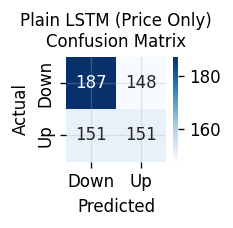

In [18]:
plain_lstm_results = run_cv_and_test(
    PlainLSTM, X_price_all, y_price_all, dates_price_all,
    tr_idx_p, vl_idx_p, te_idx_p,
    model_name='Plain LSTM (Price Only)')
all_results['Plain LSTM'] = plain_lstm_results

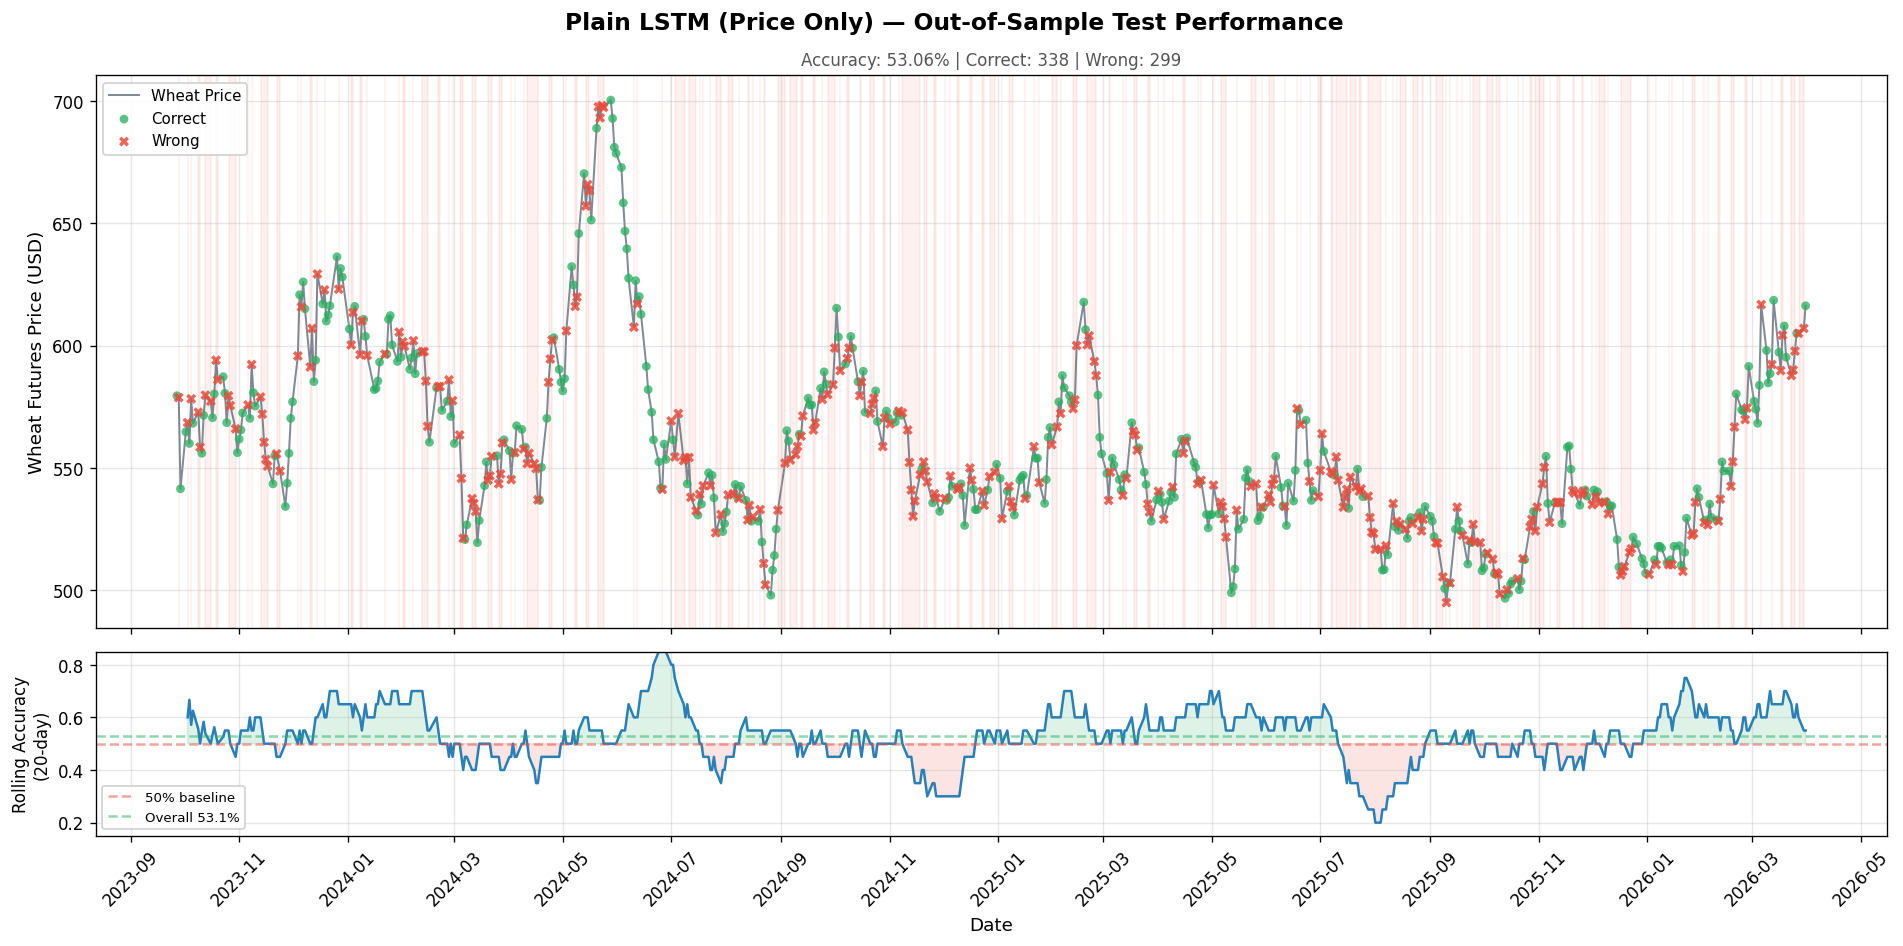

In [19]:
plot_out_of_sample(plain_lstm_results, 'Plain LSTM (Price Only)', price_series)

### 7b. LSTM Base (Price + Decayed Sentiment)

In [ ]:
lstm_base_results = run_cv_and_test(
    LSTMBase, X_sent_all, y_sent_all, dates_sent_all,
    tr_idx_s, vl_idx_s, te_idx_s,
    model_name='LSTM Base (Price + Sentiment)')
all_results['LSTM Base'] = lstm_base_results

  LSTM Base (Price + Sentiment)
  Fold 1: acc=0.5302
  Fold 2: acc=0.5117
  Fold 3: acc=0.5369
  Fold 4: acc=0.5151
  Fold 5: acc=0.4933

  Training final model on train+val, evaluating on test...


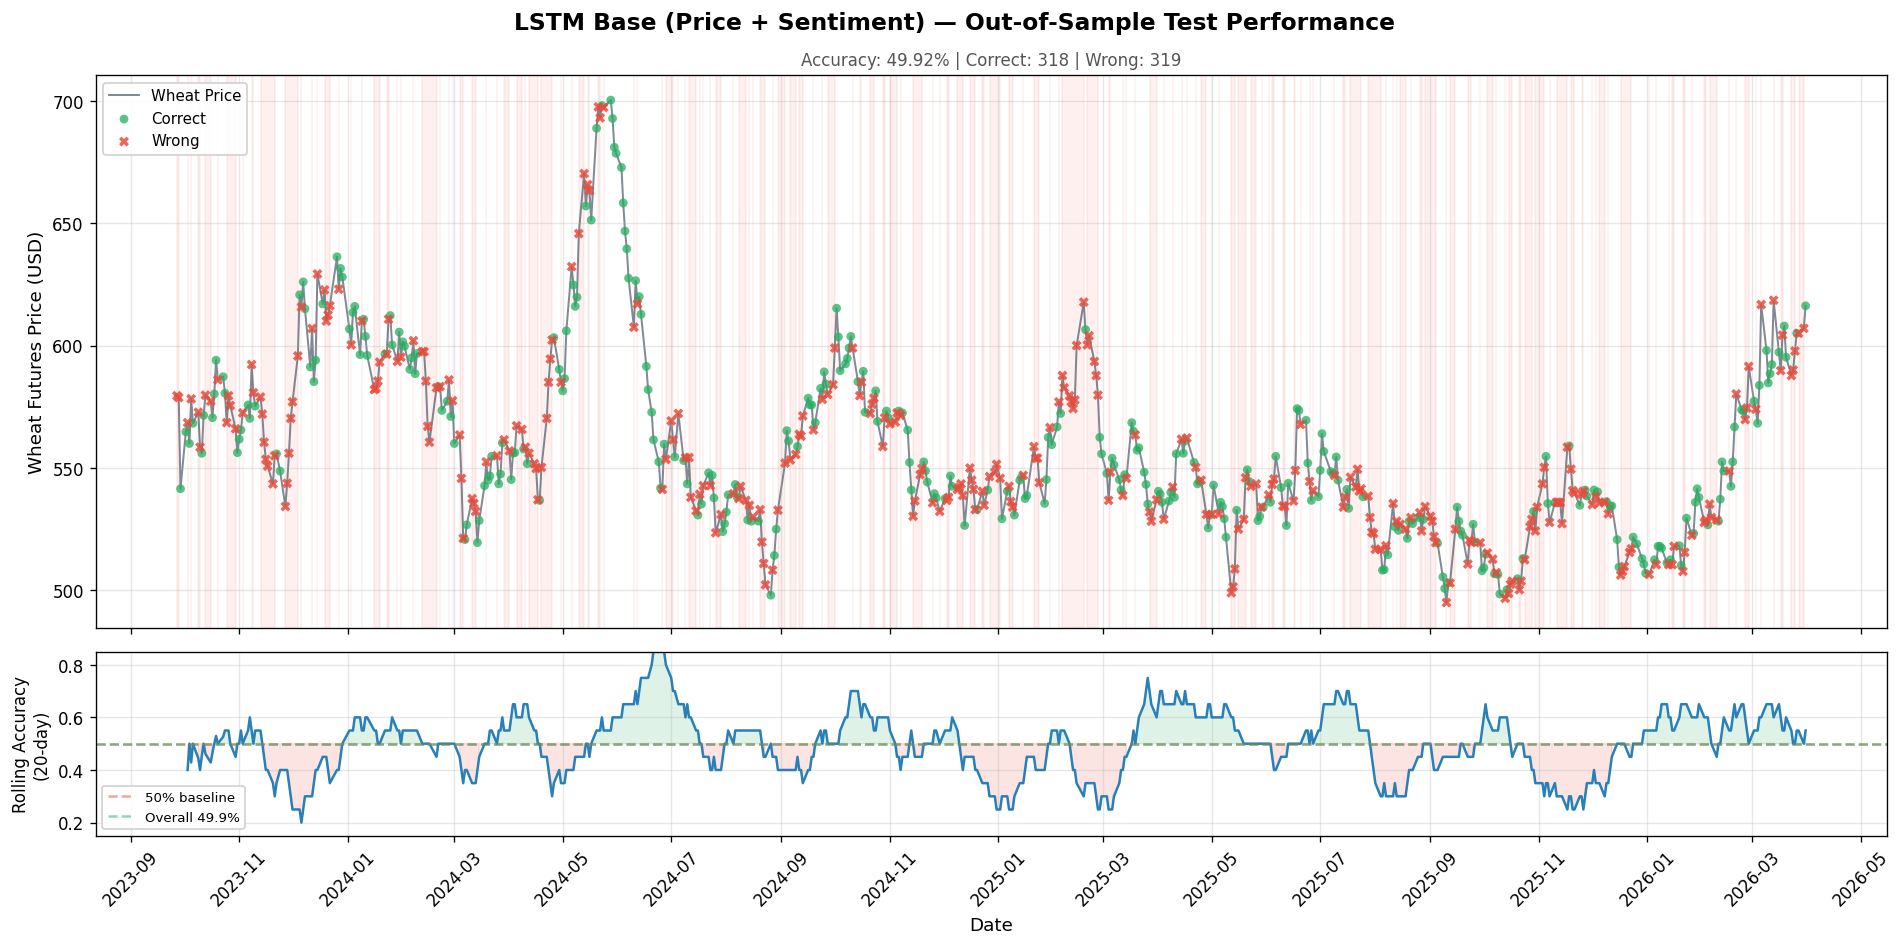

In [ ]:
plot_out_of_sample(lstm_base_results, 'LSTM Base (Price + Sentiment)', price_series)

### 7c. LSTM + Attention (Price + Decayed Sentiment)

  LSTM + Attention (Price + Sentiment)
  Fold 1: acc=0.5721
  Fold 2: acc=0.5101
  Fold 3: acc=0.5587
  Fold 4: acc=0.5419
  Fold 5: acc=0.5101

  Training final model on train+val, evaluating on test...

  TEST -> Accuracy: 0.5369 | F1: 0.4402
  Precision (Up): 0.5156 | Recall (Up): 0.3841
  Precision (Down): 0.5485 | Recall (Down): 0.6746


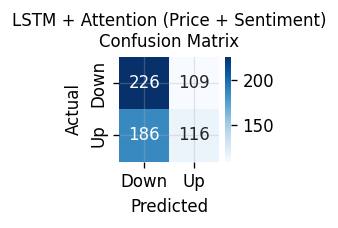

In [ ]:
lstm_attn_results = run_cv_and_test(
    LSTMAttention, X_sent_all, y_sent_all, dates_sent_all,
    tr_idx_s, vl_idx_s, te_idx_s,
    model_name='LSTM + Attention (Price + Sentiment)')
all_results['LSTM + Attention'] = lstm_attn_results

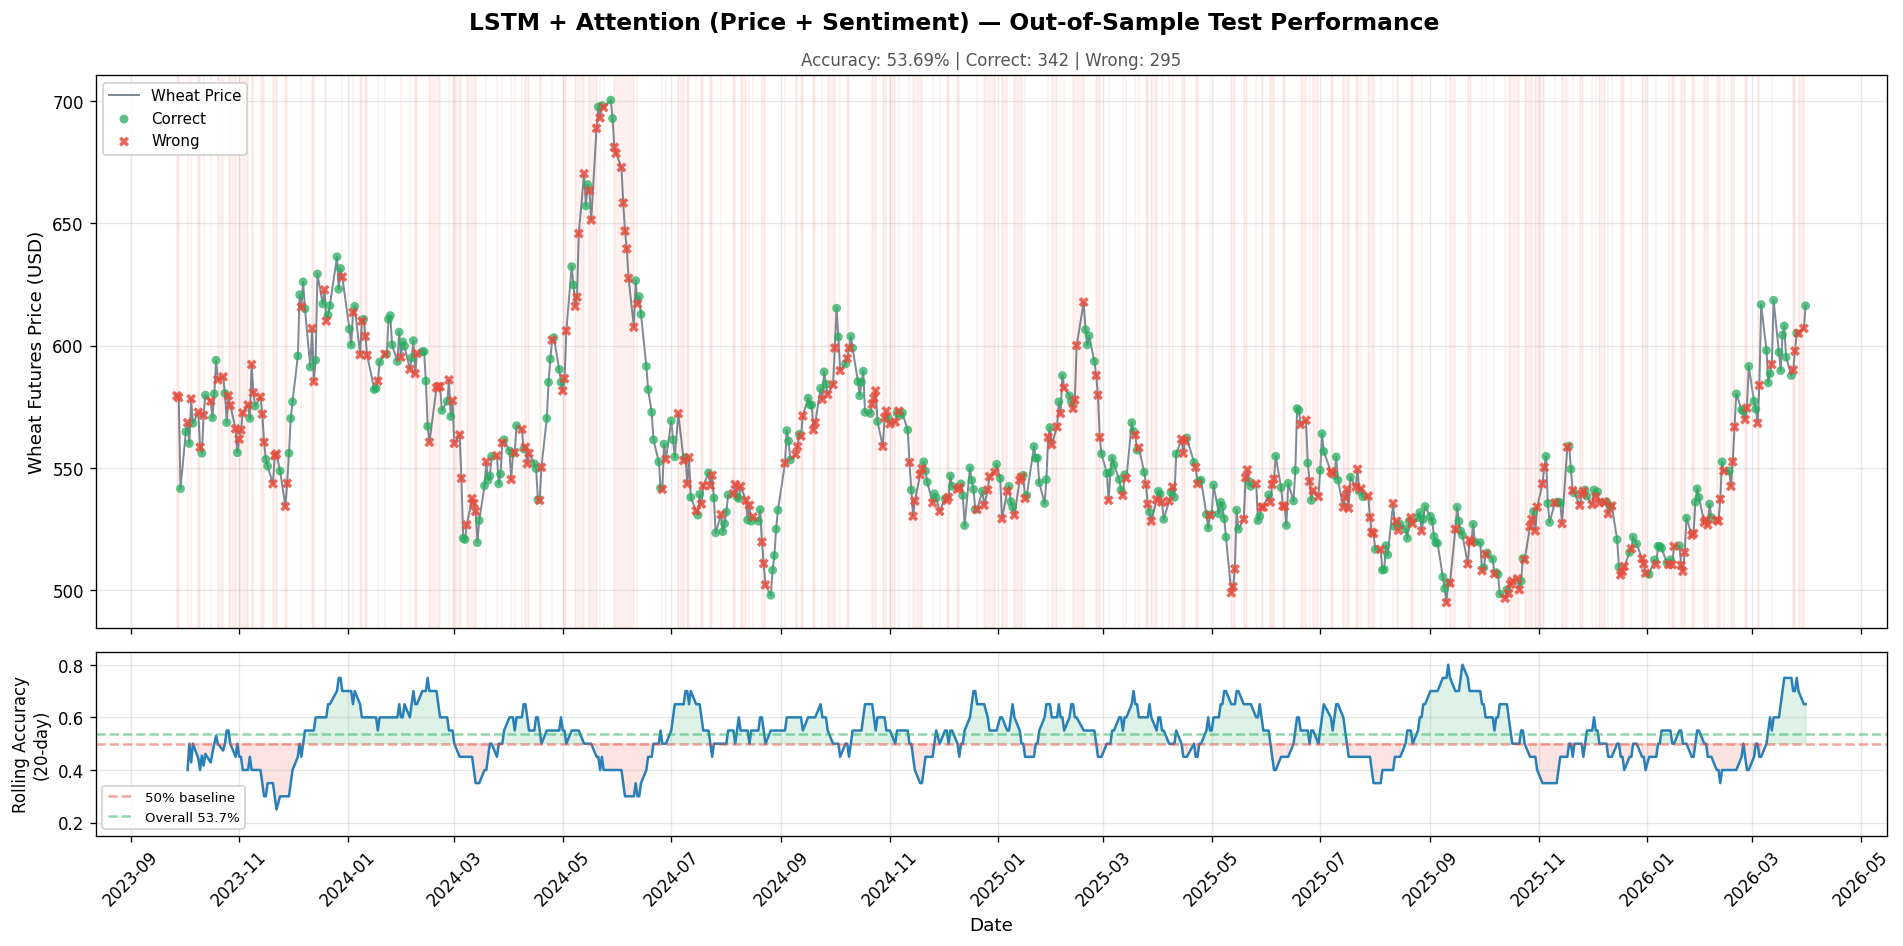

In [ ]:
plot_out_of_sample(lstm_attn_results, 'LSTM + Attention (Price + Sentiment)', price_series)

### 7d. Cross-Attention LSTM (Price + Text + Sentiment)

  Cross-Attention LSTM (Price + Text + Sentiment)
  Fold 1: acc=0.5604
  Fold 2: acc=0.5101
  Fold 3: acc=0.5352
  Fold 4: acc=0.5017
  Fold 5: acc=0.4950

  Training final model on train+val, evaluating on test...

  TEST -> Accuracy: 0.5133 | F1: 0.4561
  Precision (Up): 0.4851 | Recall (Up): 0.4305
  Precision (Down): 0.5339 | Recall (Down): 0.5881


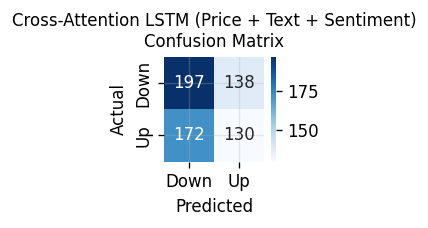

In [ ]:
cross_attn_results = run_cv_and_test(
    CrossAttentionLSTM, X_full_all, y_full_all, dates_full_all,
    tr_idx_f, vl_idx_f, te_idx_f,
    X_text=X_text_all, X_mask=X_mask_all,
    model_name='Cross-Attention LSTM (Price + Text + Sentiment)')
all_results['Cross-Attention'] = cross_attn_results

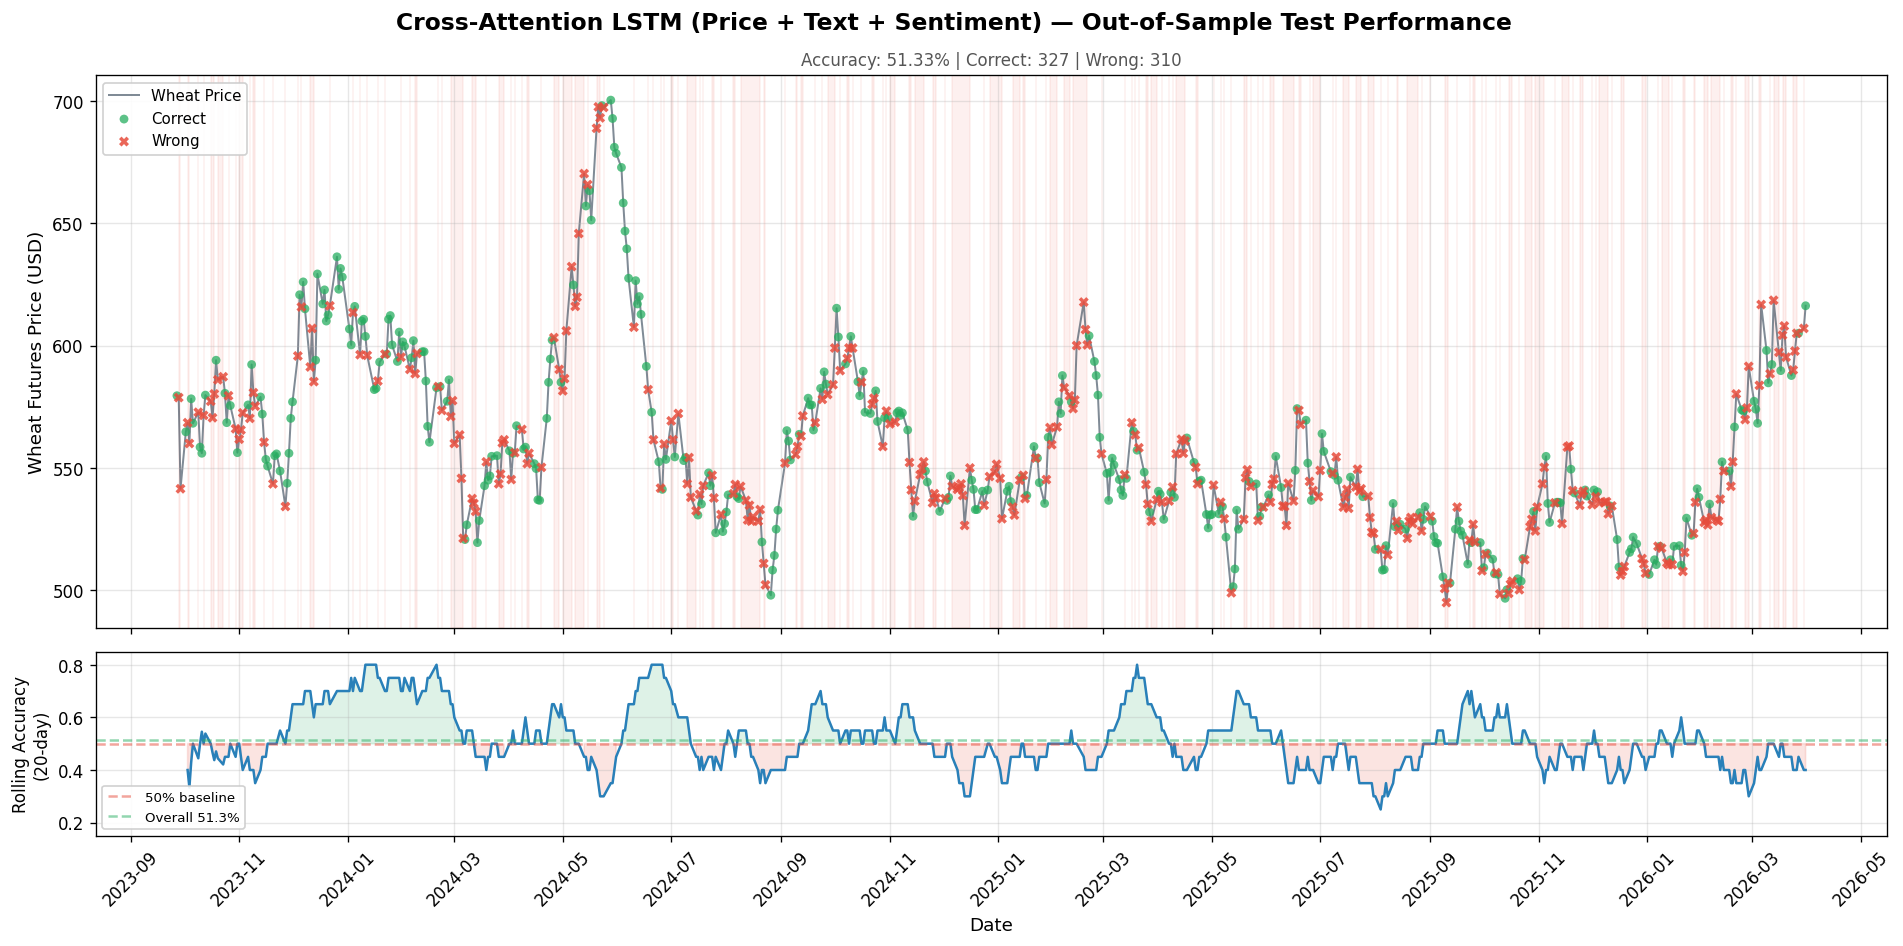

In [ ]:
plot_out_of_sample(cross_attn_results, 'Cross-Attention LSTM (Price + Text + Sentiment)', price_series)

### 7e. Dual-Attention LSTM (Price + Text + Sentiment)

  Dual-Attention LSTM (Price + Text + Sentiment)
  Fold 1: acc=0.5218
  Fold 2: acc=0.4983
  Fold 3: acc=0.5403
  Fold 4: acc=0.5268
  Fold 5: acc=0.5034

  Training final model on train+val, evaluating on test...

  TEST -> Accuracy: 0.5353 | F1: 0.3884
  Precision (Up): 0.5165 | Recall (Up): 0.3113
  Precision (Down): 0.5429 | Recall (Down): 0.7373


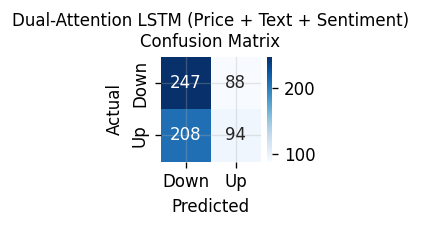

In [ ]:
dual_attn_results = run_cv_and_test(
    DualAttentionLSTM, X_full_all, y_full_all, dates_full_all,
    tr_idx_f, vl_idx_f, te_idx_f,
    X_text=X_text_all, X_mask=X_mask_all,
    model_name='Dual-Attention LSTM (Price + Text + Sentiment)')
all_results['Dual-Attention'] = dual_attn_results

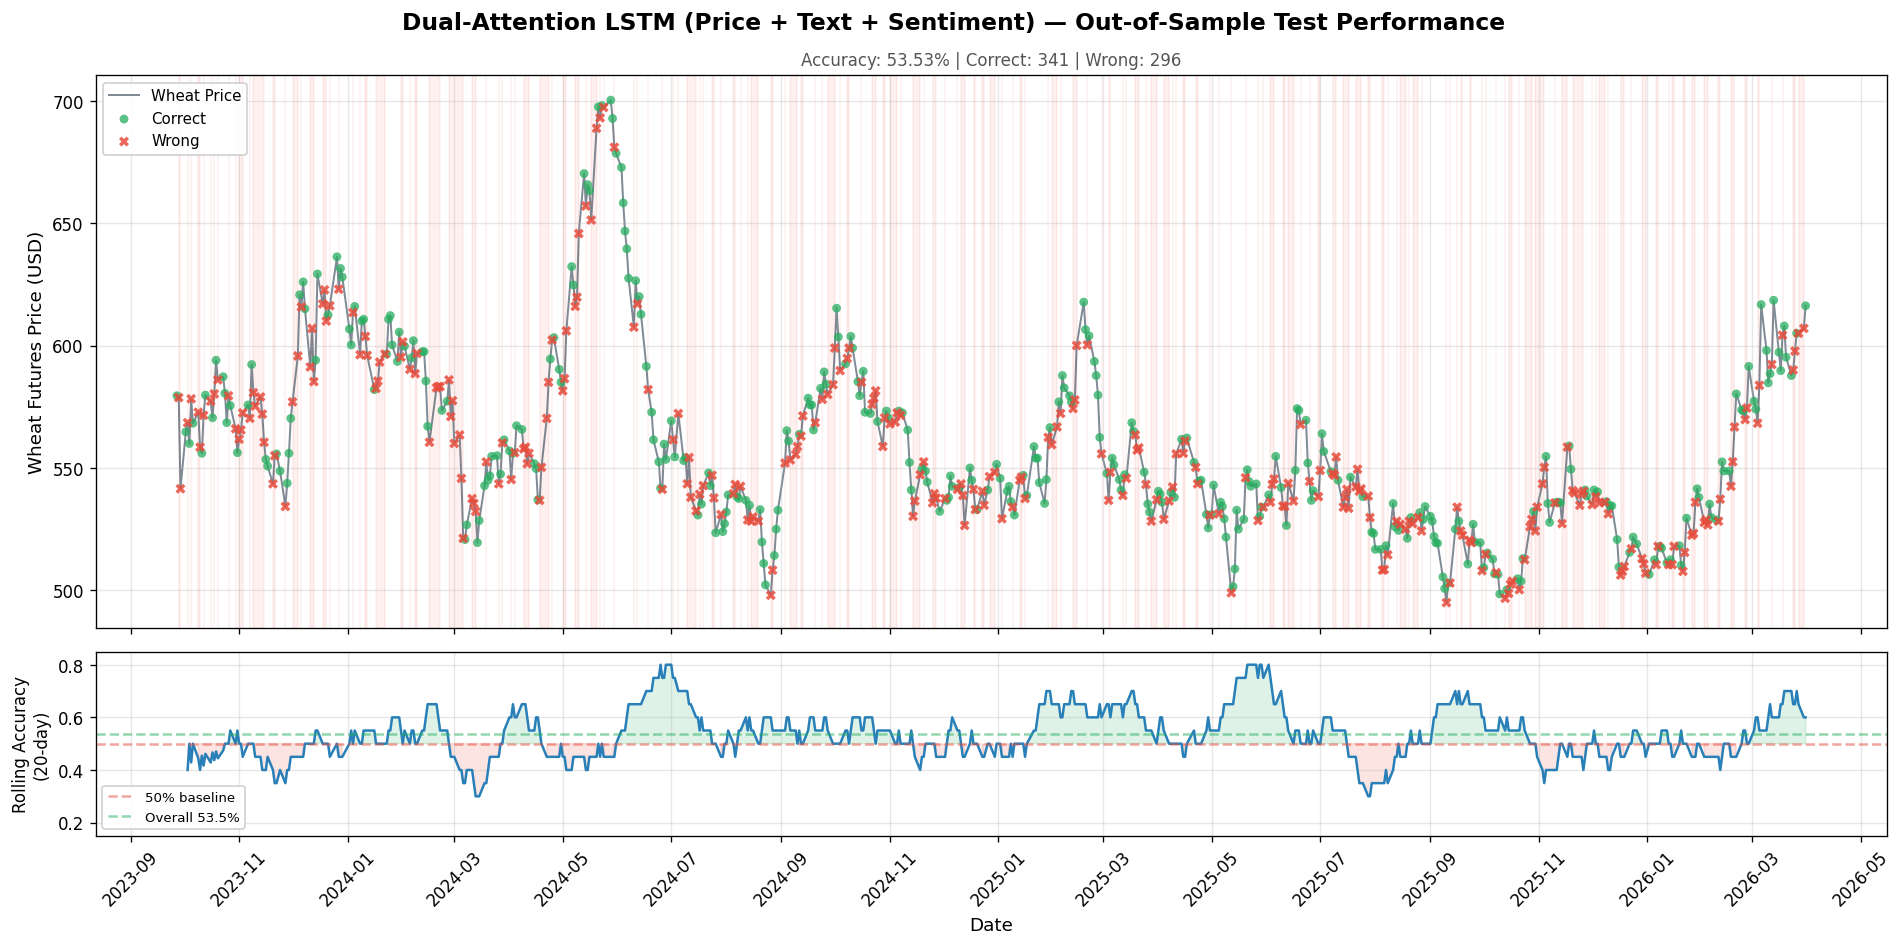

In [ ]:
plot_out_of_sample(dual_attn_results, 'Dual-Attention LSTM (Price + Text + Sentiment)', price_series)

## 8. Comparative Model Evaluation

In [ ]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary_rows = {}
for name, res in all_results.items():
    summary_rows[name] = {
        'Accuracy':       res['acc'],
        'F1 Score':       res['f1'],
        'Precision (Up)': res['prec_up'],
        'Recall (Up)':    res['rec_up'],
        'Precision (Down)': res['prec_down'],
        'Recall (Down)':  res['rec_down'],
    }

df_results = pd.DataFrame(summary_rows).T
df_results = df_results.round(4)
print("="*70)
print("  COMPARATIVE TEST-SET RESULTS")
print("="*70)
print(df_results.to_string())
print()

# Highlight best per metric
for col in df_results.columns:
    best_model = df_results[col].idxmax()
    print(f"  Best {col}: {best_model} ({df_results.loc[best_model, col]:.4f})")

  COMPARATIVE TEST-SET RESULTS
                  Accuracy  F1 Score  Precision (Up)  Recall (Up)  Precision (Down)  Recall (Down)
Plain LSTM          0.5306    0.5025          0.5050       0.5000            0.5533         0.5582
LSTM Base           0.4992    0.4657          0.4712       0.4603            0.5234         0.5343
LSTM + Attention    0.5369    0.4402          0.5156       0.3841            0.5485         0.6746
Cross-Attention     0.5133    0.4561          0.4851       0.4305            0.5339         0.5881
Dual-Attention      0.5353    0.3884          0.5165       0.3113            0.5429         0.7373

  Best Accuracy: LSTM + Attention (0.5369)
  Best F1 Score: Plain LSTM (0.5025)
  Best Precision (Up): Dual-Attention (0.5165)
  Best Recall (Up): Plain LSTM (0.5000)
  Best Precision (Down): Plain LSTM (0.5533)
  Best Recall (Down): Dual-Attention (0.7373)


### Comparative Visualizations

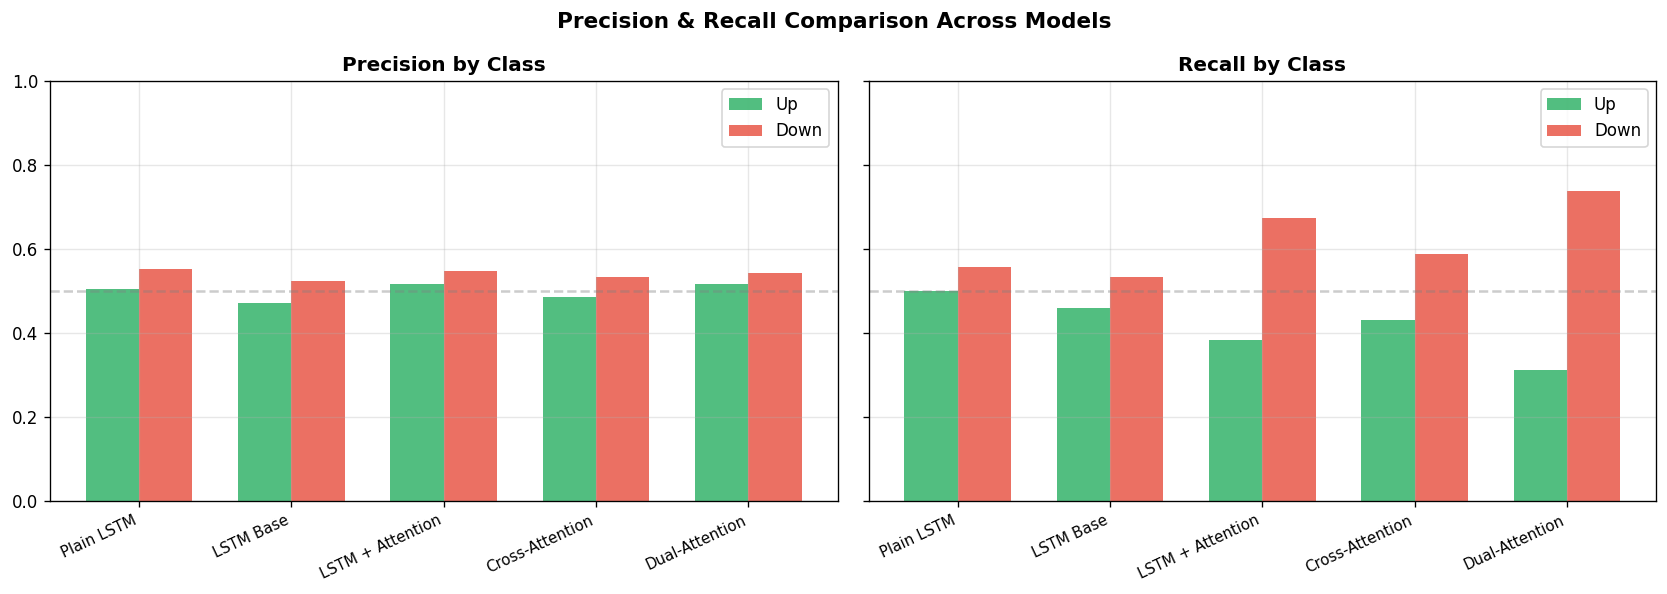

In [ ]:
# ── Grouped bar chart: Precision & Recall ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

models = list(all_results.keys())
x = np.arange(len(models))
width = 0.35

prec_up   = [all_results[m]['prec_up'] for m in models]
prec_down = [all_results[m]['prec_down'] for m in models]
rec_up    = [all_results[m]['rec_up'] for m in models]
rec_down  = [all_results[m]['rec_down'] for m in models]

axes[0].bar(x - width/2, prec_up, width, label='Up', color='#27AE60', alpha=0.8)
axes[0].bar(x + width/2, prec_down, width, label='Down', color='#E74C3C', alpha=0.8)
axes[0].set_title('Precision by Class', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=25, ha='right', fontsize=9)
axes[0].legend()
axes[0].set_ylim(0, 1)
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.4)

axes[1].bar(x - width/2, rec_up, width, label='Up', color='#27AE60', alpha=0.8)
axes[1].bar(x + width/2, rec_down, width, label='Down', color='#E74C3C', alpha=0.8)
axes[1].set_title('Recall by Class', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=25, ha='right', fontsize=9)
axes[1].legend()
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.4)

plt.suptitle('Precision & Recall Comparison Across Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

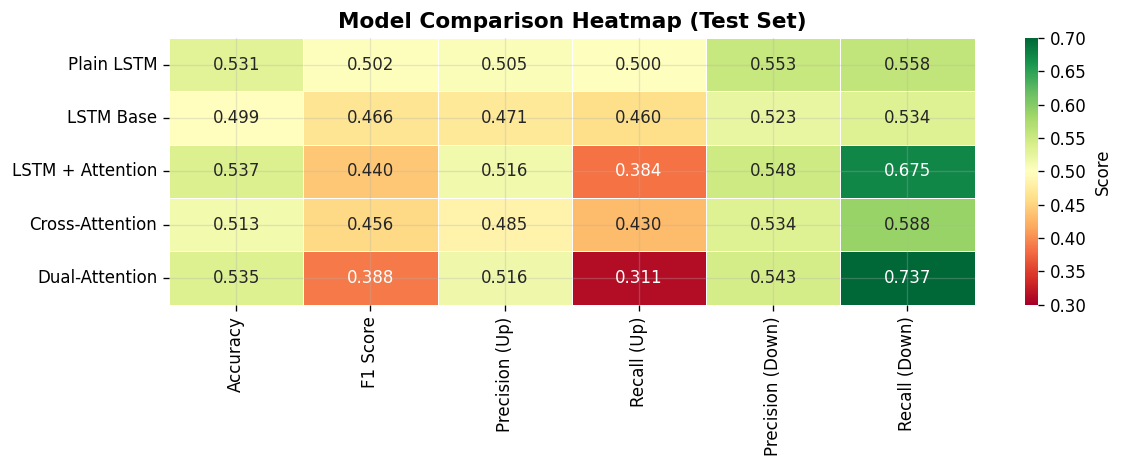

In [ ]:
# ── Heatmap of all metrics ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(df_results.astype(float), annot=True, fmt='.3f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, vmin=0.3, vmax=0.7,
            cbar_kws={'label': 'Score'})
ax.set_title('Model Comparison Heatmap (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

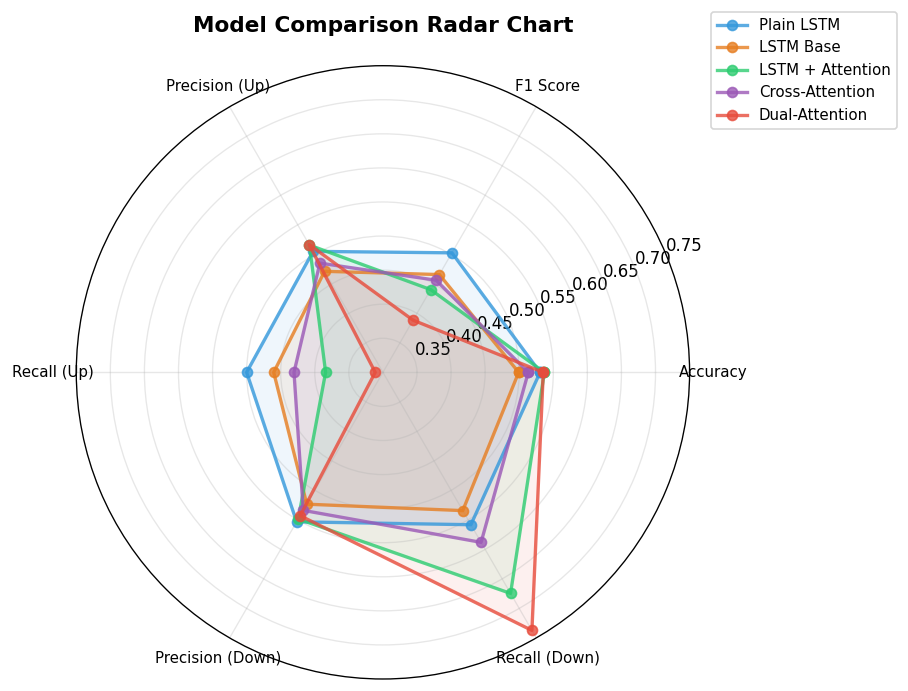

In [ ]:
# ── Radar / Spider chart ──────────────────────────────────────────────────────
metrics = list(df_results.columns)
N = len(metrics)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = ['#3498DB', '#E67E22', '#2ECC71', '#9B59B6', '#E74C3C']

for i, (model_name, row) in enumerate(df_results.iterrows()):
    values = row.values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=model_name,
            color=colors[i % len(colors)], alpha=0.8)
    ax.fill(angles, values, alpha=0.08, color=colors[i % len(colors)])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, size=9)
ax.set_ylim(0.3, 0.75)
ax.set_title('Model Comparison Radar Chart', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.show()